In [39]:
# Pressure Drop Detection and Storm-Risk Expert System
import os
import json
import requests

from datetime import datetime

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window

import matplotlib.pyplot as plt

# Spark Session

spark = SparkSession.builder \
    .appName("Storm Risk Expert System") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("Storm Risk Expert System")

print(f"Spark version : {spark.version}")
print()

# API Config

TOKEN = "STUDENT_TOKEN_2026"

BASE_URL = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev"

HEADERS = {
    "Authorization": f"Bearer {TOKEN}"
}

STATION_ID = "GDN_01"

LIMIT = 100

# Folders

os.makedirs("raw_data", exist_ok=True)
os.makedirs("processed", exist_ok=True)
os.makedirs("plots", exist_ok=True)

print("Folders ready.")
print("Project initialized.")

Storm Risk Expert System
Spark version : 4.0.3

Folders ready.
Project initialized.


In [40]:
#Download Weather Data from REST API

print("Downloading weather data...")

response = requests.get(
    f"{BASE_URL}/weather/batch",
    headers=HEADERS,
    params={
        "station_id": STATION_ID,
        "limit": LIMIT
    }
)

response.raise_for_status()

data = response.json()

raw_file = f"raw_data/weather_raw_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

with open(raw_file, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

print("Download completed.")
print(f"Raw file saved:\n{raw_file}")

# Preview API response
print("\nResponse type:", type(data))

if isinstance(data, list):
    print("Number of elements:", len(data))

elif isinstance(data, dict):
    print("Keys:", list(data.keys()))

Download completed.
Raw file saved:
raw_data/weather_raw_20260628_212003.json

Response type: <class 'dict'>
Keys: ['station_id', 'count', 'records']


In [41]:
import pandas as pd

pdf = pd.DataFrame(data["records"])

spark_df = spark.createDataFrame(pdf)

print("\nSchema")

spark_df.printSchema()

print("\nFirst rows")

spark_df.show(5, truncate=False)

print("\nNumber of records:", spark_df.count())


Schema
root
 |-- timestamp: string (nullable = true)
 |-- station_id: string (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- wind_direction: long (nullable = true)
 |-- rain_mm: double (nullable = true)
 |-- cloud_cover: long (nullable = true)


First rows
+--------------------------------+----------+-----------+--------+--------+----------+--------------+-------+-----------+
|timestamp                       |station_id|temperature|humidity|pressure|wind_speed|wind_direction|rain_mm|cloud_cover|
+--------------------------------+----------+-----------+--------+--------+----------+--------------+-------+-----------+
|2026-06-28T21:20:03.190334+00:00|GDN_01    |14.71      |61.34   |1023.25 |5.39      |106           |0.52   |6          |
|2026-06-28T21:10:03.190334+00:00|GDN_01    |19.71      |51.42   |1010.01 |4.95      |191           |0.0    |71   

In [42]:
#Data Validation and Cleaning

print("DATA VALIDATION")

# Remove duplicated rows
spark_df = spark_df.dropDuplicates()

# Remove rows with NULL values in important columns
required_columns = [
    "timestamp",
    "pressure",
    "wind_speed",
    "rain_mm",
    "cloud_cover"
]

spark_df = spark_df.dropna(subset=required_columns)

# Convert timestamp

spark_df = spark_df.withColumn(
    "timestamp",
    to_timestamp(col("timestamp"))
)

# Remove rows with invalid timestamp

spark_df = spark_df.filter(col("timestamp").isNotNull())

print("Records after validation:", spark_df.count())

spark_df.show(5)

DATA VALIDATION
Records after validation: 100
+--------------------+----------+-----------+--------+--------+----------+--------------+-------+-----------+
|           timestamp|station_id|temperature|humidity|pressure|wind_speed|wind_direction|rain_mm|cloud_cover|
+--------------------+----------+-----------+--------+--------+----------+--------------+-------+-----------+
|2026-06-28 18:30:...|    GDN_01|       18.3|   48.15| 1024.12|      1.54|           118|   0.99|         69|
|2026-06-28 20:50:...|    GDN_01|      18.37|    90.2| 1024.96|       0.1|           182|    0.0|         39|
|2026-06-28 14:10:...|    GDN_01|      17.41|   93.85| 1008.38|      4.08|            57|    0.0|         26|
|2026-06-28 15:10:...|    GDN_01|       19.7|   77.87| 1028.73|      3.61|           282|    0.0|         63|
|2026-06-28 16:40:...|    GDN_01|      18.82|    65.8| 1014.77|      3.21|           340|   0.38|          8|
+--------------------+----------+-----------+--------+--------+----------+

In [43]:
#Pressure Trend Analysis

print("PRESSURE ANALYSIS")

window = Window.orderBy("timestamp")

spark_df = spark_df.withColumn(
    "pressure_delta",
    col("pressure") - lag("pressure").over(window)
)

rolling_window = Window.orderBy("timestamp").rowsBetween(-4, 0)

spark_df = spark_df.withColumn(
    "pressure_rolling",
    avg("pressure").over(rolling_window)
)

spark_df.select(
    "timestamp",
    "pressure",
    "pressure_delta",
    "pressure_rolling"
).show(10, truncate=False)

PRESSURE ANALYSIS
+--------------------------+--------+-------------------+------------------+
|timestamp                 |pressure|pressure_delta     |pressure_rolling  |
+--------------------------+--------+-------------------+------------------+
|2026-06-28 04:50:03.190334|1020.58 |NULL               |1020.58           |
|2026-06-28 05:00:03.190334|1014.46 |-6.1200000000000045|1017.52           |
|2026-06-28 05:10:03.190334|1024.8  |10.339999999999918 |1019.9466666666667|
|2026-06-28 05:20:03.190334|1014.17 |-10.629999999999995|1018.5025         |
|2026-06-28 05:30:03.190334|1000.0  |-14.169999999999959|1014.802          |
|2026-06-28 05:40:03.190334|1021.94 |21.940000000000055 |1015.074          |
|2026-06-28 05:50:03.190334|1027.15 |5.210000000000036  |1017.6119999999999|
|2026-06-28 06:00:03.190334|1002.67 |-24.480000000000132|1013.186          |
|2026-06-28 06:10:03.190334|1012.89 |10.220000000000027 |1012.9300000000001|
|2026-06-28 06:20:03.190334|1027.53 |14.639999999999986 |1

In [44]:
#Expert System

print("EXPERT SYSTEM")

spark_df = spark_df.withColumn("score", lit(0))

# Pressure
# Larger pressure drops may indicate unstable weather.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("pressure_delta") <= -10, 3)
    .when(col("pressure_delta") <= -5, 2)
    .when(col("pressure_delta") <= -2, 1)
    .otherwise(0)
)

# Pressure below rolling average
# A pressure value lower than the recent rolling average may indicate an approaching low-pressure system.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("pressure") < col("pressure_rolling") - 3, 2)
    .when(col("pressure") < col("pressure_rolling") - 1, 1)
    .otherwise(0)
)

# Wind
# Strong wind may be associated with weather fronts.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("wind_speed") >= 12, 3)
    .when(col("wind_speed") >= 8, 2)
    .when(col("wind_speed") >= 5, 1)
    .otherwise(0)
)

# Rain
# Rain may indicate big rain clouds

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("rain_mm") >= 2, 3)
    .when(col("rain_mm") >= 1, 2)
    .when(col("rain_mm") > 0, 1)
    .otherwise(0)
)

# Clouds
# High cloud cover may be a sign of unstable weather.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("cloud_cover") >= 90, 3)
    .when(col("cloud_cover") >= 70, 2)
    .when(col("cloud_cover") >= 50, 1)
    .otherwise(0)
)

# More advanced calculation rules

# Rapid pressure drop together with strong wind increases the probability of storm development.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(
        (col("pressure_delta") <= -5) &
        (col("wind_speed") >= 8),
        2
    ).otherwise(0)
)

# Pressure drop and rainfall indicate an active weather front.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(
        (col("pressure_delta") <= -5) &
        (col("rain_mm") > 0),
        1
    ).otherwise(0)
)

# Dense cloud cover together with strong wind suggests unstable conditions.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(
        (col("cloud_cover") >= 90) &
        (col("wind_speed") >= 10),
        2
    ).otherwise(0)
)

# If all major indicators occur together, increase the confidence of storm detection.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(
        (col("pressure_delta") <= -5) &
        (col("wind_speed") >= 8) &
        (col("cloud_cover") >= 90) &
        (col("rain_mm") > 0),
        3
    ).otherwise(0)
)

# Classification
# LOW - stable conditions
# MEDIUM - several warning indicators
# HIGH - multiple strong indicators detected

spark_df = spark_df.withColumn(
    "storm_risk",
    when(col("score") >= 11, "HIGH")
    .when(col("score") >= 6, "MEDIUM")
    .otherwise("LOW")
)

spark_df.select(
    "timestamp",
    "pressure",
    "pressure_delta",
    "wind_speed",
    "rain_mm",
    "cloud_cover",
    "score",
    "storm_risk"
).show(20, truncate=False)

EXPERT SYSTEM
+--------------------------+--------+-------------------+----------+-------+-----------+-----+----------+
|timestamp                 |pressure|pressure_delta     |wind_speed|rain_mm|cloud_cover|score|storm_risk|
+--------------------------+--------+-------------------+----------+-------+-----------+-----+----------+
|2026-06-28 04:50:03.190334|1020.58 |NULL               |8.17      |2.08   |54         |6    |MEDIUM    |
|2026-06-28 05:00:03.190334|1014.46 |-6.1200000000000045|13.26     |1.56   |34         |12   |HIGH      |
|2026-06-28 05:10:03.190334|1024.8  |10.339999999999918 |0.65      |0.0    |80         |2    |LOW       |
|2026-06-28 05:20:03.190334|1014.17 |-10.629999999999995|13.02     |1.65   |3          |13   |HIGH      |
|2026-06-28 05:30:03.190334|1000.0  |-14.169999999999959|8.83      |1.4    |55         |13   |HIGH      |
|2026-06-28 05:40:03.190334|1021.94 |21.940000000000055 |7.17      |1.62   |31         |3    |LOW       |
|2026-06-28 05:50:03.190334|1027

In [45]:
# Alert Log

from pyspark.sql.functions import current_timestamp, monotonically_increasing_id

print("ALERT LOG")

alerts = (
    spark_df
    .filter(col("storm_risk") == "HIGH")
    .withColumn("alert_id", monotonically_increasing_id() + 1)
    .withColumn("generated_at", current_timestamp())
)

print(f"Number of HIGH alerts: {alerts.count()}")

alerts.select(
    "alert_id",
    "generated_at",
    "timestamp",
    "pressure",
    "pressure_delta",
    "wind_speed",
    "rain_mm",
    "cloud_cover",
    "score",
    "storm_risk"
).show(truncate=False)

ALERT LOG
Number of HIGH alerts: 13
+--------+--------------------------+--------------------------+--------+-------------------+----------+-------+-----------+-----+----------+
|alert_id|generated_at              |timestamp                 |pressure|pressure_delta     |wind_speed|rain_mm|cloud_cover|score|storm_risk|
+--------+--------------------------+--------------------------+--------+-------------------+----------+-------+-----------+-----+----------+
|1       |2026-06-28 21:20:05.466052|2026-06-28 05:00:03.190334|1014.46 |-6.1200000000000045|13.26     |1.56   |34         |12   |HIGH      |
|2       |2026-06-28 21:20:05.466052|2026-06-28 05:20:03.190334|1014.17 |-10.629999999999995|13.02     |1.65   |3          |13   |HIGH      |
|3       |2026-06-28 21:20:05.466052|2026-06-28 05:30:03.190334|1000.0  |-14.169999999999959|8.83      |1.4    |55         |13   |HIGH      |
|4       |2026-06-28 21:20:05.466052|2026-06-28 07:20:03.190334|1003.41 |-23.620000000000005|11.55     |0.61   |

In [46]:
#Save Results

spark_df.write.mode("overwrite").parquet(
    "processed/weather_curated.parquet"
)

spark_df.coalesce(1).write.mode("overwrite").option(
    "header",
    True
).csv("processed/weather_processed_csv")

alerts.coalesce(1).write.mode("overwrite").option(
    "header",
    True
).csv("processed/storm_alerts_csv")

print("Files saved successfully.")

Files saved successfully.


In [47]:
#Statistics

print("PROJECT STATISTICS")

print("Number of measurements:", spark_df.count())

spark_df.groupBy("storm_risk").count().show()

print("Number of HIGH alerts:", alerts.count())

PROJECT STATISTICS
Number of measurements: 100
+----------+-----+
|storm_risk|count|
+----------+-----+
|    MEDIUM|   28|
|      HIGH|   13|
|       LOW|   59|
+----------+-----+

Number of HIGH alerts: 13


In [52]:
#High Risk Case

print("HIGHEST RISK SINGLE CASE")

case = spark_df.orderBy(col("score").desc())

case.select(
    "timestamp",
    "pressure",
    "pressure_delta",
    "pressure_rolling",
    "wind_speed",
    "rain_mm",
    "cloud_cover",
    "score",
    "storm_risk"
).show(1, truncate=False)

HIGHEST RISK SINGLE CASE
+--------------------------+--------+-------------------+------------------+----------+-------+-----------+-----+----------+
|timestamp                 |pressure|pressure_delta     |pressure_rolling  |wind_speed|rain_mm|cloud_cover|score|storm_risk|
+--------------------------+--------+-------------------+------------------+----------+-------+-----------+-----+----------+
|2026-06-28 18:10:03.190334|1010.49 |-12.450000000000045|1014.1940000000001|9.65      |1.3    |92         |18   |HIGH      |
+--------------------------+--------+-------------------+------------------+----------+-------+-----------+-----+----------+
only showing top 1 row


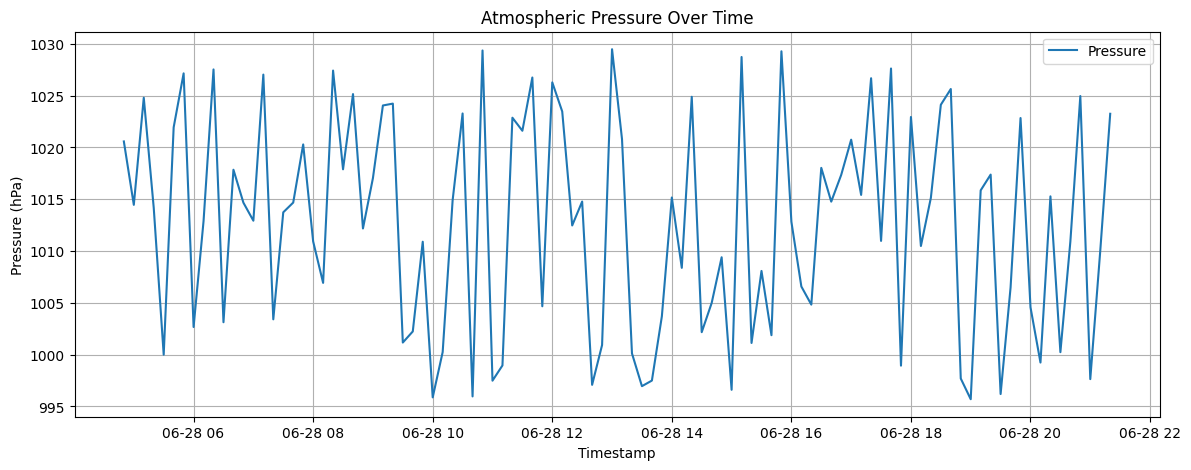

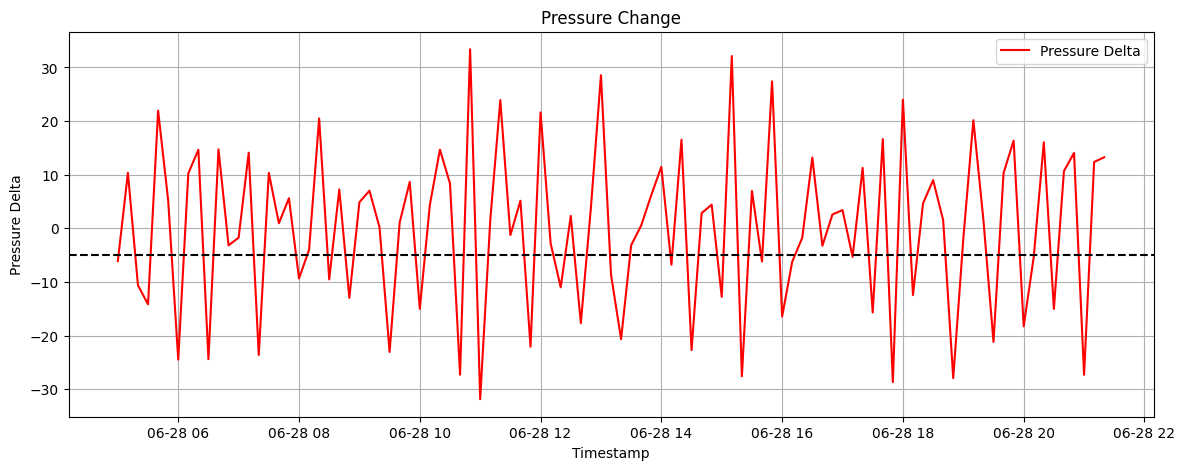

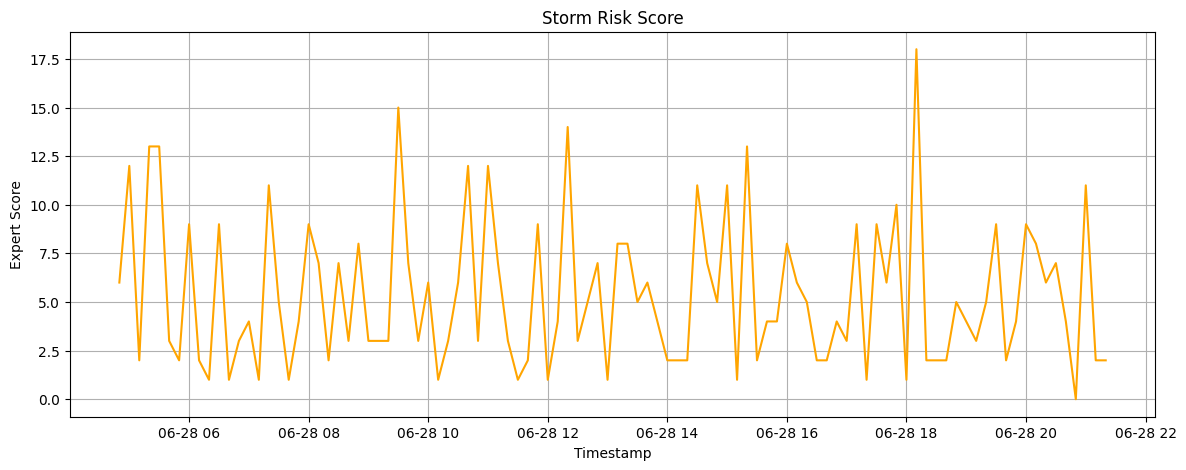

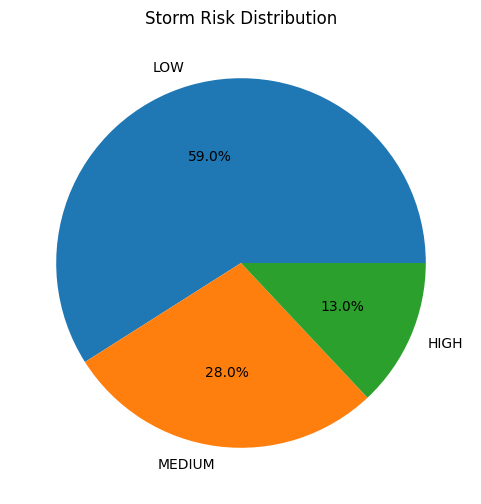

,timestamp,station_id,temperature,humidity,pressure,wind_speed,wind_direction,rain_mm,cloud_cover,pressure_delta,pressure_rolling,score,storm_risk
0,2026-06-28 04:50:03.190334,GDN_01,15.96,57.45,1020.58,8.17,84,2.08,54,NaN,1020.580000,6,MEDIUM
1,2026-06-28 05:00:03.190334,GDN_01,16.90,88.61,1014.46,13.26,107,1.56,34,-6.12,1017.520000,12,HIGH
2,2026-06-28 05:10:03.190334,GDN_01,13.02,92.21,1024.80,0.65,8,0.00,80,10.34,1019.946667,2,LOW
3,2026-06-28 05:20:03.190334,GDN_01,16.12,50.42,1014.17,13.02,261,1.65,3,-10.63,1018.502500,13,HIGH
4,2026-06-28 05:30:03.190334,GDN_01,14.91,80.55,1000.00,8.83,107,1.40,55,-14.17,1014.802000,13,HIGH


In [51]:
#Dashboard

#Preasure

plt.figure(figsize=(14,5))

plt.plot(
    plot_df["timestamp"],
    plot_df["pressure"],
    label="Pressure"
)

plt.title("Atmospheric Pressure Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Pressure (hPa)")
plt.grid(True)
plt.legend()

plt.show()

#Preasure delta

plt.figure(figsize=(14,5))

plt.plot(
    plot_df["timestamp"],
    plot_df["pressure_delta"],
    color="red",
    label="Pressure Delta"
)

plt.axhline(-5, color="black", linestyle="--")

plt.title("Pressure Change")
plt.xlabel("Timestamp")
plt.ylabel("Pressure Delta")
plt.grid(True)
plt.legend()

plt.show()

#Storm risk score

plt.figure(figsize=(14,5))

plt.plot(
    plot_df["timestamp"],
    plot_df["score"],
    color="orange"
)

plt.title("Storm Risk Score")
plt.xlabel("Timestamp")
plt.ylabel("Expert Score")
plt.grid(True)

plt.show()

#Alert count

risk_counts = (
    plot_df["storm_risk"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%"
)

plt.title("Storm Risk Distribution")

plt.show()

plot_df = spark_df.orderBy("timestamp").toPandas()

plot_df.head()